In [ ]:
#데이터 최신화 함수
import requests
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta
import pandas as pd

def update_fish_data(
    service_key = 'c6480da403e57fc0f6680c5bf4fb689db235eae8efbc9796e0e290a5d8c85f09',
    min_daily_count=50
):
    df = pd.read_csv('data3.csv')

    url = 'http://apis.data.go.kr/1192000/select0040List/getselect0040List'

    # 🔥 시장 리스트
    markets = [
        '강릉시수산업협동조합',
        '강원고성군수산업협동조합',
        '동해시수산업협동조합',
        '삼척수산업협동조합',
        '속초시수산업협동조합',
        '양양수산업협동조합',
        '죽변수산업협동조합',
        '영덕북부수산업협동조합',
        '포항수산업협동조합'
    ]

    # 🔥 어종 리스트
    fish_list = [
        '문어',
        '가자미',
        '넙치',
        '대게',
        '대구',
        '아귀'
    ]

    # 🔥 날짜 변환
    df['위판일자'] = pd.to_datetime(df['위판일자'])

    # 🔥 마지막 날짜
    last_date = df['위판일자'].max()

    # 🔥 다음 날짜부터
    start_date = last_date + timedelta(days=1)

    # 🔥 현재 날짜
    end_date = datetime.today() - timedelta(days=1)

    # 🔥 최신 여부 확인
    if start_date > end_date:

        print("이미 최신 데이터입니다.")

        return 0

    print(f"{start_date.date()} ~ {end_date.date()} 데이터 수집 시작")

    all_items = []

    current_date = start_date

    while current_date <= end_date:

        baseDt = current_date.strftime('%Y%m%d')

        daily_items = []

        for market in markets:

            for fish in fish_list:

                params = {
                    'serviceKey': service_key,
                    'numOfRows': '100',
                    'type': 'xml',
                    'baseDt': baseDt,
                    'mxtrNm': market,
                    'mprcStdCodeNm': fish
                }

                try:

                    # 🔥 페이지 최대 5
                    for page in range(1, 6):

                        params['pageNo'] = str(page)

                        response = requests.get(
                            url,
                            params=params,
                            timeout=5
                        )

                        if response.status_code != 200:
                            break

                        xml_str = response.content.decode('utf-8')

                        root = ET.fromstring(xml_str)

                        items = root.findall('.//item')

                        # 🔥 데이터 없으면 종료
                        if not items:
                            break

                        for item in items:

                            weight = float(
                                item.findtext('csmtWt', 0) or 0
                            )

                            amount = int(
                                item.findtext('csmtAmount', 0) or 0
                            )

                            # 🔥 중량 0 제거
                            if weight <= 0:
                                continue

                            row = {
                                "위판일자": item.findtext('csmtDe'),
                                "산지조합명": market,
                                "수산물표준코드명": item.findtext('mprcStdCodeNm'),
                                "위판중량": weight,
                                "위판금액": amount,
                                "단가": amount / weight
                            }

                            daily_items.append(row)

                except Exception as e:

                    print(f"{baseDt} / {market} / {fish} 에러:", e)

        # 🔥 하루 데이터 개수 조건
        if len(daily_items) > min_daily_count:

            all_items.extend(daily_items)

            print(f"{baseDt} 완료 ({len(daily_items)}개)")

        else:

            print(f"{baseDt} 데이터 부족 ({len(daily_items)}개)")

        current_date += timedelta(days=1)

    # 🔥 신규 데이터 없으면 종료
    if len(all_items) == 0:

        print("신규 데이터 없음")

        return 0

    # 🔥 DataFrame 생성
    new_df = pd.DataFrame(all_items)

    # 🔥 날짜 변환
    new_df['위판일자'] = pd.to_datetime(new_df['위판일자'])

    # 🔥 기존 데이터와 합치기
    updated_df = pd.concat(
        [df, new_df],
        ignore_index=True
    )

    # 🔥 날짜 정렬
    updated_df = updated_df.sort_values('위판일자')

    # 🔥 인덱스 초기화
    updated_df = updated_df.reset_index(drop=True)

    updated_df['위판일자'] = pd.to_datetime(updated_df['위판일자'])

    # 필요없는 어종 제거
    updated_df['수산물표준코드명'] = updated_df['수산물표준코드명'].astype(str).str.strip()
    
    # 🔥 남길 어종 리스트
    target_fish = [
        '문어', '대문어',
        '가자미류', '기름가자미', '참가자미', '홍가자미',
        '대구', '대구류',
        '아귀', '넙치',
        '대게',
        '가자미'
    ]
    
    # 🔥 필터링
    df_filter = updated_df[
        updated_df['수산물표준코드명'].isin(target_fish)
    ].copy()
    
    # 🔥 어종 통합 매핑
    fish_map = {
        '대문어': '문어',
        '기름가자미': '가자미',
        '참가자미': '가자미',
        '홍가자미': '가자미',
        '가자미류': '가자미',
    
        '대구류': '대구',
    
    }
    # 🔥 어종 통합
    df_filter['수산물표준코드명'] = df_filter['수산물표준코드명'].replace(fish_map)
    df_filter = (
        df_filter
        .sort_values('위판일자')
        .reset_index(drop=True)
    )
    df_filter.to_csv('data3.csv', index=False, encoding='utf-8-sig')

    print("업데이트 완료")
    print(df_filter.shape)

In [3]:
#어종 분리 코드
import os
import pandas as pd

def split_fish_data(
    input_file='data3.csv',
    save_dir='fish_split'
):
    # 🔥 데이터 불러오기
    df = pd.read_csv(input_file)

    # 🔥 날짜 변환
    df['위판일자'] = pd.to_datetime(df['위판일자'])

    # 🔥 저장 폴더 생성
    os.makedirs(save_dir, exist_ok=True)

    # 🔥 어종명 공백 제거
    df['수산물표준코드명'] = (
        df['수산물표준코드명']
        .astype(str)
        .str.strip()
    )

    # 🔥 어종별 분리 저장
    for fish, group in df.groupby('수산물표준코드명'):

        # 🔥 파일 경로
        file_path = os.path.join(
            save_dir,
            f'{fish}.csv'
        )

        # 🔥 날짜 정렬
        group = (
            group
            .sort_values('위판일자')
            .reset_index(drop=True)
        )

        # 🔥 저장
        group.to_csv(
            file_path,
            index=False,
            encoding='utf-8-sig'
        )

        print(f'{fish}: {len(group)}개 저장 완료')

    print('전체 어종 분리 완료')

In [4]:
#이상치 제거 및 일별 가중평균 단가 계산 함수
import pandas as pd

def make_daily_price(fish_name):
    # 🔥 파일 불러오기
    df = pd.read_csv(f'fish_split/{fish_name}.csv')

    # 날짜 변환
    df['위판일자'] = pd.to_datetime(df['위판일자'])

    # 🔥 단가 생성 (없으면)
    if '단가' not in df.columns:
        df['단가'] = df['위판금액'] / df['위판중량']

    # 🔥 중량 0 제거
    df = df[df['위판중량'] > 0]

    # 🔥 IQR 이상치 제거
    Q1 = df['단가'].quantile(0.25)
    Q3 = df['단가'].quantile(0.75)

    df_clean = df[
        (df['단가'] >= Q1) &
        (df['단가'] <= Q3)
    ]

    # 🔥 가중평균 단가 계산
    df_daily = (
        df_clean.groupby('위판일자')
        .apply(
            lambda x: (
                (x['단가'] * x['위판중량']).sum()
                / x['위판중량'].sum()
            ),
            include_groups=False
        )
        .reset_index(name='단가')
    )

    # 날짜 정렬
    df_daily = df_daily.sort_values('위판일자')

    # 저장
    save_dir = 'fish_daily'
    os.makedirs(save_dir, exist_ok=True)
    file_path = os.path.join(save_dir, f'{fish_name}.csv')
    df_daily.to_csv(file_path , index=False, encoding='utf-8-sig')

    print(f'{fish_name} 완료')
    print(df_daily.head())

    return df_daily

In [5]:
import pandas as pd
import requests
from datetime import datetime, timedelta
#날짜 데이터 최신화 코드
def update_weather_data(station='22105', auth_key="fGT1dw_mS9mk9XcP5jvZIw"):
    df1 = pd.read_csv('날씨.csv')

    # 🔥 마지막 날짜 확인
    last_date = pd.to_datetime(df1['date']).max()

    # 🔥 다음 시점부터 시작
    start_date = last_date + timedelta(hours=1)

    # 🔥 현재 시각
    end_date = datetime.now()

    # 🔥 최신 여부 확인
    if start_date.date() >= end_date.date():
        print("이미 최신 데이터입니다.")
        return None

    print(f"{start_date} ~ {end_date} 데이터 수집 시작")

    tm1 = start_date.strftime("%Y%m%d%H%M")
    tm2 = end_date.strftime("%Y%m%d%H%M")

    print(f"{tm1} ~ {tm2} 데이터 요청")

    url = (
        f"https://apihub.kma.go.kr/api/typ01/url/kma_buoy2.php?"
        f"tm1={tm1}"
        f"&tm2={tm2}"
        f"&stn={station}"
        f"&help=0"
        f"&authKey={auth_key}"
    )
    try:
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            print("요청 실패:", response.status_code)
            return None

        raw_text = response.text

    except Exception as e:
        print("에러:", e)
        return None


    # 1️⃣ 줄 단위 분리
    lines = raw_text.split("\n")
    
    # 2️⃣ 필요한 데이터만 필터링
    data_lines = []
    for line in lines:
        line = line.strip()
        
        if not line:
            continue
        if line.startswith("#"):
            continue
        
        data_lines.append(line)
    
    # 3️⃣ 컬럼 정의 (위 주석 기준)
    columns = [
        "datetime", "stn", 
        "wd1", "ws1", "ws1_gst",
        "wd2", "ws2", "ws2_gst",
        "pa", "hm", "ta", "tw",
        "wh_max", "wh_sig", "wh_ave",
        "wp", "wo", "aqc", "mqc", "end"
    ]
    
    # 4️⃣ DataFrame 생성
    data = [line.split(",") for line in data_lines]
    df = pd.DataFrame(data, columns=columns)
    
    # 5️⃣ 마지막 '=' 컬럼 제거
    df = df.drop(columns=["end"])
    
    # 6️⃣ 타입 변환
    numeric_cols = df.columns.drop(["datetime", "aqc", "mqc"])
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    
    # 7️⃣ datetime 변환
    df["datetime"] = pd.to_datetime(df["datetime"], format="%Y%m%d%H%M")
    
    # 확인
    df = df.drop(columns=['stn', 'wd1', 'wd2', 'ws2', 'ws2_gst', 'ta', 'wo','aqc','mqc','ws1_gst','hm','wh_max','wh_ave'], errors='ignore')
    df['date'] = df['datetime'].dt.date
    df_daily = df.groupby('date').agg({
        'ws1': 'mean',
        'pa': 'mean',
        'tw': 'mean',
        'wh_sig': 'mean',
        'wp': 'mean'
    }).reset_index()
    updated_df = pd.concat([df1, df_daily], ignore_index=True)
    updated_df = updated_df.drop_duplicates(subset=['date'])
    
    updated_df.to_csv('날씨.csv', index=False, encoding='utf-8-sig')
    print('저장 완료')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_fish_model(fish_name):

    # 🔥 데이터 불러오기
    df = pd.read_csv(f'fish_daily/{fish_name}.csv')
    wt = pd.read_csv('날씨.csv')

    # 🔥 날짜 변환
    df['위판일자'] = pd.to_datetime(df['위판일자'])
    wt['date'] = pd.to_datetime(wt['date'])

    # 🔥 merge
    df = pd.merge(
        df,
        wt,
        left_on='위판일자',
        right_on='date',
        how='left'
    )

    # 🔥 중복 컬럼 제거
    df = df.drop(columns=['date'])

    # 🔥 날짜 정렬
    df = df.sort_values('위판일자')

    # 🔥 lag feature
    df['lag_1'] = df['단가'].shift(1)
    df['lag_7'] = df['단가'].shift(7)

    # 🔥 rolling 평균
    df['rolling_mean_7'] = (
        df['단가']
        .rolling(7)
        .mean()
    )

    # 🔥 시간 변수
    df['month'] = df['위판일자'].dt.month
    df['dayofweek'] = df['위판일자'].dt.dayofweek

    # 🔥 NaN 제거
    df = df.dropna()

    # 🔥 feature 목록
    features = [
        'lag_1',
        'lag_7',
        'rolling_mean_7',
        'month',
        'dayofweek',
        'ws1',
        'pa',
        'tw',
        'wh_sig',
        'wp',
    ]

    # 🔥 X / y
    X = df[features]
    y = df['단가']

    # 🔥 모델 생성
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    # 🔥 학습
    model.fit(X, y)

    # 🔥 예측
    pred = model.predict(X)

    # 🔥 평가
    mae = mean_absolute_error(y, pred)

    rmse = np.sqrt(
        mean_squared_error(y, pred)
    )

    r2 = r2_score(y, pred)

    # 🔥 출력
    print(f'{fish_name} 모델 평가')
    print(f'MAE  : {mae:.2f}')
    print(f'RMSE : {rmse:.2f}')
    print(f'R2   : {r2:.4f}')

    # 🔥 그래프
    plt.figure(figsize=(15, 6))

    # 실제값
    plt.plot(
        df['위판일자'],
        y,
        label='Actual'
    )

    # 예측값
    plt.plot(
        df['위판일자'],
        pred,
        label='Predicted'
    )

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Actual vs Predicted')

    plt.legend()

    plt.show()

    return {
        'model': model,
        'df': df,
        'X': X,
        'y': y,
        'pred': pred,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    }

In [7]:
import pandas as pd
import requests
from datetime import timedelta


def predict_7days(result, lat=37.530, lon=130.000):

    # 🔥 모델 / 데이터 가져오기
    model = result['model']
    df = result['df']

    # 🔥 미래 날씨 예보 가져오기
    weather_url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}"
        f"&longitude={lon}"
        f"&hourly=wind_speed_10m,pressure_msl"
        f"&forecast_days=8"
        f"&timezone=Asia%2FSeoul"
    )

    marine_url = (
        f"https://marine-api.open-meteo.com/v1/marine?"
        f"latitude={lat}"
        f"&longitude={lon}"
        f"&hourly=wave_height,wave_period,sea_surface_temperature"
        f"&forecast_days=8"
        f"&timezone=Asia%2FSeoul"
    )

    # 🔥 요청
    w_res = requests.get(weather_url).json()
    m_res = requests.get(marine_url).json()

    # 🔥 DataFrame 생성
    df_w = pd.DataFrame(w_res['hourly'])
    df_m = pd.DataFrame(m_res['hourly'])

    df_w['time'] = pd.to_datetime(df_w['time'])
    df_m['time'] = pd.to_datetime(df_m['time'])

    # 🔥 병합
    weather_df = pd.merge(
        df_w,
        df_m,
        on='time',
        how='inner'
    )

    # 🔥 날짜 컬럼
    weather_df['date'] = weather_df['time'].dt.date

    # 🔥 일평균
    weather_daily = (
        weather_df
        .groupby('date')
        .agg({
            'wind_speed_10m': 'mean',
            'pressure_msl': 'mean',
            'sea_surface_temperature': 'mean',
            'wave_height': 'mean',
            'wave_period': 'mean'
        })
        .reset_index()
    )

    # 🔥 컬럼명 통일
    weather_daily.columns = [
        'date',
        'ws1',
        'pa',
        'tw',
        'wh_sig',
        'wp'
    ]

    # =========================
    # 🔥 미래 7일 예측
    # =========================

    future_preds = []

    temp_df = df.copy()

    for i in range(7):

        future_date = (
            temp_df['위판일자'].max()
            + timedelta(days=1)
        )

        weather_row = weather_daily.iloc[i]

        # 🔥 feature 생성
        next_input = pd.DataFrame([{

            'lag_1':
                temp_df.iloc[-1]['단가'],

            'lag_7':
                temp_df.iloc[-7]['단가'],

            'rolling_mean_7':
                temp_df['단가'].tail(7).mean(),

            'month':
                future_date.month,

            'dayofweek':
                future_date.dayofweek,

            'ws1':
                weather_row['ws1'],

            'pa':
                weather_row['pa'],

            'tw':
                weather_row['tw'],

            'wh_sig':
                weather_row['wh_sig'],

            'wp':
                weather_row['wp'],
        }])

        # 🔥 예측
        pred_price = model.predict(next_input)[0]

        # 🔥 저장
        future_preds.append({
            '위판일자': future_date,
            '예측단가': pred_price
        })

        # 🔥 다음 예측용으로 추가
        new_row = temp_df.iloc[-1].copy()

        new_row['위판일자'] = future_date
        new_row['단가'] = pred_price

        temp_df = pd.concat([
            temp_df,
            pd.DataFrame([new_row])
        ], ignore_index=True)

    # 🔥 결과 DataFrame
    pred_df = pd.DataFrame(future_preds)

    print(pred_df)

    return pred_df

In [8]:
#전체 예측
import pandas as pd

# =========================
# 전체 어종 예측 함수
# =========================

def predict_all_fish():
    update_fish_data()
    update_weather_data()
    split_fish_data()

    fish_list = [
        '문어',
        '가자미',
        '넙치',
        '대게',
        '대구',
        '아귀'
    ]

    result_list = []

    for fish in fish_list:
        make_daily_price(fish)

        try:

            print(f'\n===== {fish} 예측 시작 =====')

            # 모델 생성
            result = evaluate_fish_model(fish)

            # 7일 예측
            pred_df = predict_7days(result)

            # 필요한 컬럼만
            pred_df = pred_df[['위판일자', '예측단가']]

            # 컬럼명 변경
            pred_df = pred_df.rename(
                columns={
                    '예측단가': fish
                }
            )

            result_list.append(pred_df)

            print(f'{fish} 완료')

        except Exception as e:

            print(f'{fish} 에러:', e)

    # =========================
    # 날짜 기준 merge
    # =========================

    final_df = result_list[0]

    for df in result_list[1:]:

        final_df = pd.merge(
            final_df,
            df,
            on='위판일자',
            how='outer'
        )

    # 날짜 정렬
    final_df = final_df.sort_values('위판일자')

    print('\n전체 예측 완료')

    return final_df

2026-05-11 ~ 2026-05-11 데이터 수집 시작
20260511 완료 (1064개)
업데이트 완료
(3341793, 6)
2026-05-11 01:00:00 ~ 2026-05-12 09:51:01.278242 데이터 수집 시작
202605110100 ~ 202605120951 데이터 요청
저장 완료
가자미: 1165601개 저장 완료
넙치: 189009개 저장 완료
대게: 49766개 저장 완료
대구: 548040개 저장 완료
문어: 1238298개 저장 완료
아귀: 151079개 저장 완료
전체 어종 분리 완료
문어 완료
        위판일자            단가
0 2023-05-01  27957.360785
1 2023-05-02  27845.380318
2 2023-05-03  26764.205383
3 2023-05-04  26927.364275
4 2023-05-05  27106.368419

===== 문어 예측 시작 =====
문어 모델 평가
MAE  : 158.02
RMSE : 215.19
R2   : 0.9894


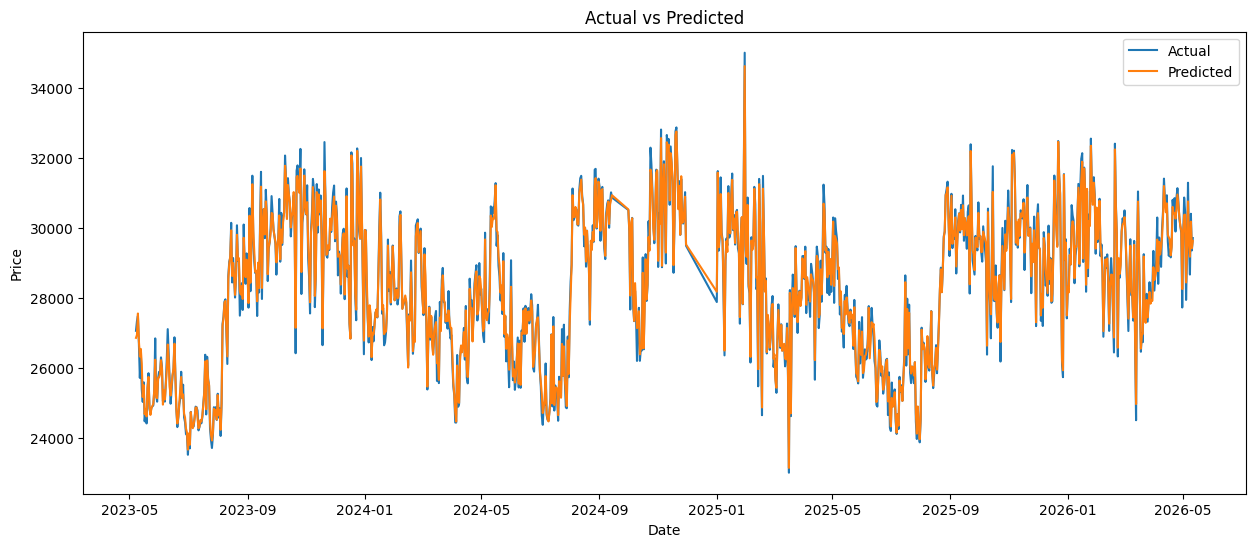

        위판일자          예측단가
0 2026-05-12  29514.302734
1 2026-05-13  29099.923828
2 2026-05-14  29228.648438
3 2026-05-15  29232.541016
4 2026-05-16  28821.599609
5 2026-05-17  29077.287109
6 2026-05-18  28958.539062
문어 완료
가자미 완료
        위판일자           단가
0 2023-05-01  6569.039838
1 2023-05-02  6149.235348
2 2023-05-03  6378.032043
3 2023-05-04  6253.527351
4 2023-05-05  6376.238497

===== 가자미 예측 시작 =====
가자미 모델 평가
MAE  : 63.97
RMSE : 88.03
R2   : 0.9718


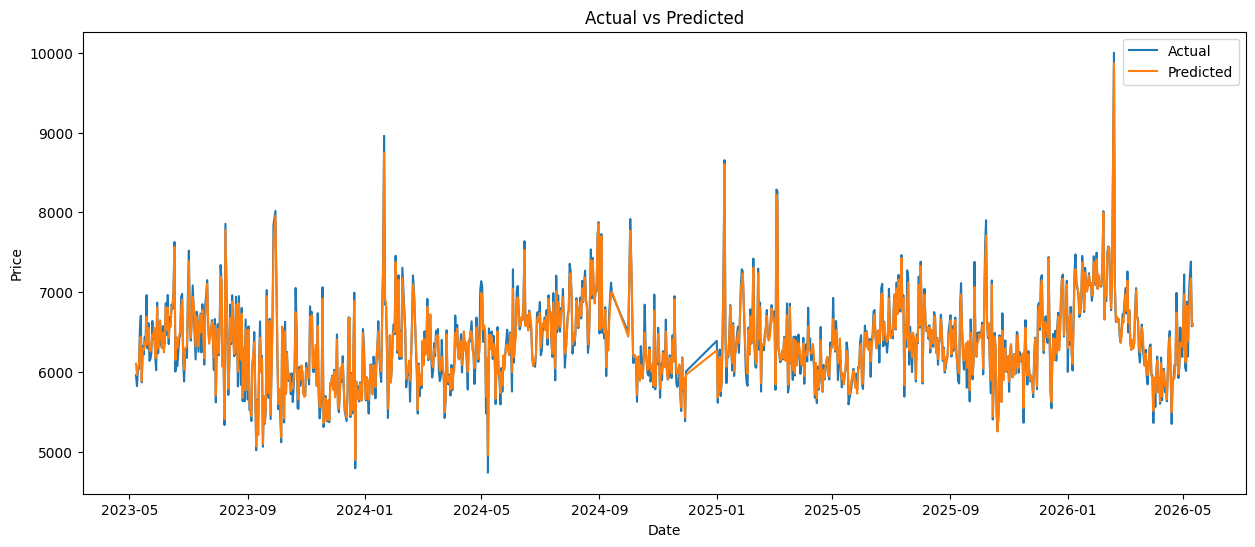

        위판일자         예측단가
0 2026-05-12  6568.249023
1 2026-05-13  6601.035645
2 2026-05-14  6589.714355
3 2026-05-15  6756.810547
4 2026-05-16  6576.647461
5 2026-05-17  6292.032227
6 2026-05-18  6426.724609
가자미 완료
넙치 완료
        위판일자            단가
0 2023-05-01  20049.960223
1 2023-05-02  17141.177966
2 2023-05-03  18855.776851
3 2023-05-04  19479.917441
4 2023-05-05  18923.478795

===== 넙치 예측 시작 =====
넙치 모델 평가
MAE  : 194.43
RMSE : 269.78
R2   : 0.9614


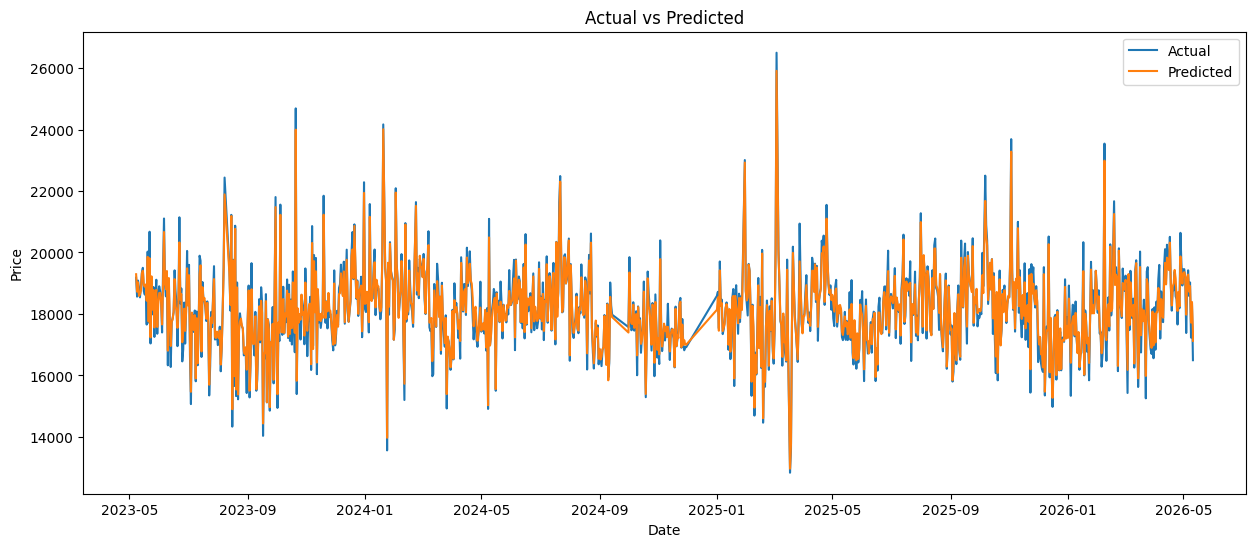

        위판일자          예측단가
0 2026-05-12  18084.246094
1 2026-05-13  17435.453125
2 2026-05-14  17533.898438
3 2026-05-15  17304.013672
4 2026-05-16  17128.908203
5 2026-05-17  17960.710938
6 2026-05-18  16892.917969
넙치 완료
대게 완료
        위판일자            단가
0 2023-05-01  28299.528302
1 2023-05-02  32447.794528
2 2023-05-03  35651.851852
3 2023-05-04  32700.923788
4 2023-05-05  21111.111111

===== 대게 예측 시작 =====
대게 모델 평가
MAE  : 333.68
RMSE : 475.22
R2   : 0.9902


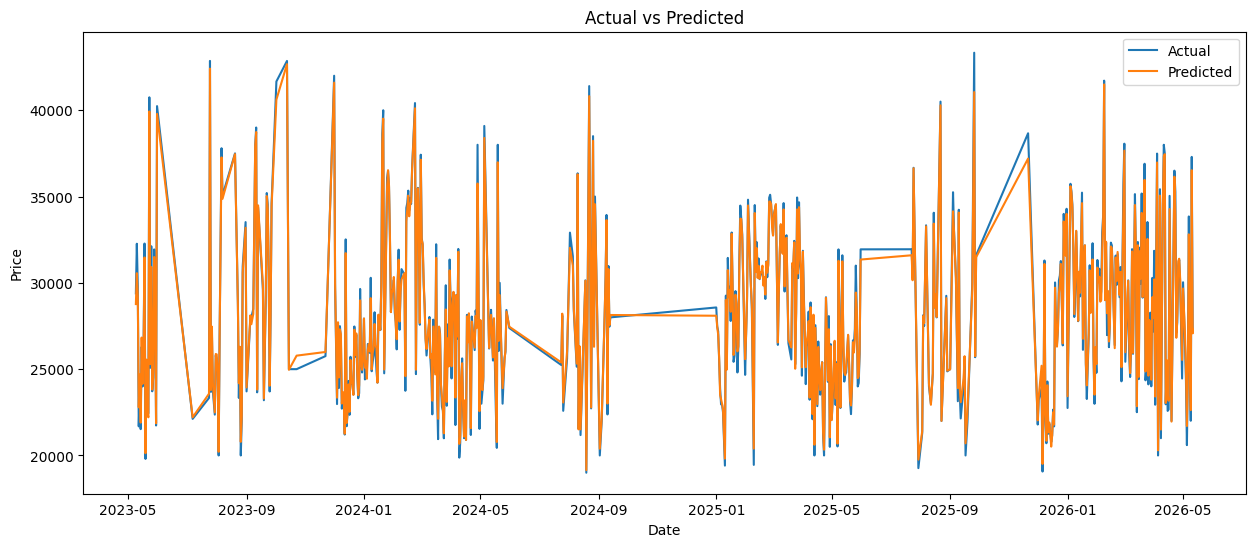

        위판일자          예측단가
0 2026-05-12  28767.671875
1 2026-05-13  29413.814453
2 2026-05-14  29403.046875
3 2026-05-15  29588.587891
4 2026-05-16  29768.351562
5 2026-05-17  31438.724609
6 2026-05-18  30704.337891
대게 완료
대구 완료
        위판일자           단가
0 2023-05-01  4481.201544
1 2023-05-02  4466.839877
2 2023-05-03  4083.697479
3 2023-05-04  4212.730072
4 2023-05-05  3902.168889

===== 대구 예측 시작 =====
대구 모델 평가
MAE  : 56.03
RMSE : 76.71
R2   : 0.9891


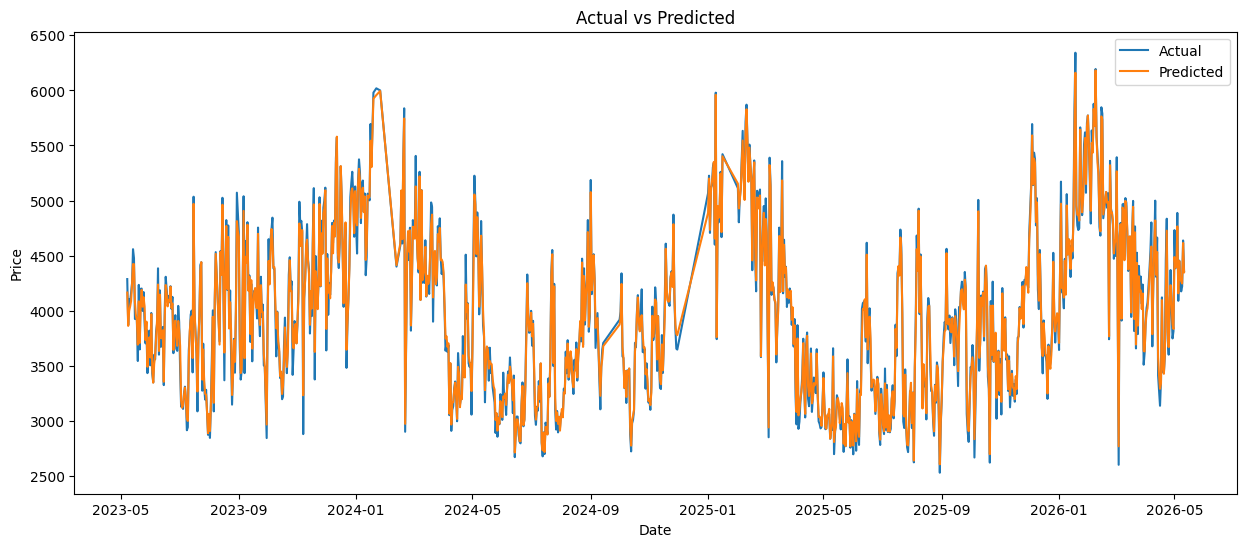

        위판일자         예측단가
0 2026-05-12  4266.700684
1 2026-05-13  4239.682129
2 2026-05-14  4136.935547
3 2026-05-15  4287.066895
4 2026-05-16  4115.771973
5 2026-05-17  4132.377441
6 2026-05-18  4116.487305
대구 완료
아귀 완료
        위판일자           단가
0 2023-05-01  6414.959016
1 2023-05-02  6567.398119
2 2023-05-03  6176.491228
3 2023-05-04  5924.038462
4 2023-05-05  6615.878378

===== 아귀 예측 시작 =====
아귀 모델 평가
MAE  : 112.73
RMSE : 151.23
R2   : 0.9660


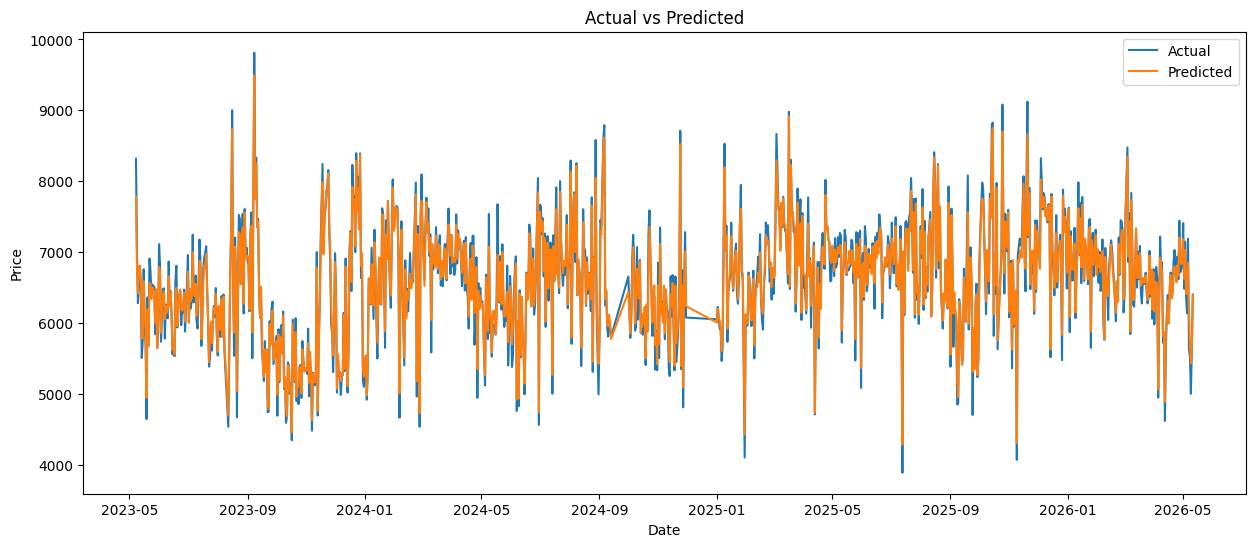

        위판일자         예측단가
0 2026-05-12  6291.937012
1 2026-05-13  6055.806152
2 2026-05-14  5661.096680
3 2026-05-15  5835.264160
4 2026-05-16  5770.350586
5 2026-05-17  5994.499023
6 2026-05-18  5816.670410
아귀 완료

전체 예측 완료


,위판일자,문어,가자미,넙치,대게,대구,아귀
0,2026-05-12,29514.302734,6568.249023,18084.246094,28767.671875,4266.700684,6291.937012
1,2026-05-13,29099.923828,6601.035645,17435.453125,29413.814453,4239.682129,6055.806152
2,2026-05-14,29228.648438,6589.714355,17533.898438,29403.046875,4136.935547,5661.096680
3,2026-05-15,29232.541016,6756.810547,17304.013672,29588.587891,4287.066895,5835.264160
4,2026-05-16,28821.599609,6576.647461,17128.908203,29768.351562,4115.771973,5770.350586
5,2026-05-17,29077.287109,6292.032227,17960.710938,31438.724609,4132.377441,5994.499023
6,2026-05-18,28958.539062,6426.724609,16892.917969,30704.337891,4116.487305,5816.670410


In [9]:
predict_all_fish()

이미 최신 데이터입니다.
이미 최신 데이터입니다.
가자미: 1165260개 저장 완료
넙치: 188946개 저장 완료
대게: 49762개 저장 완료
대구: 547888개 저장 완료
문어: 1237892개 저장 완료
아귀: 151069개 저장 완료
전체 어종 분리 완료
문어 완료
        위판일자            단가
0 2023-05-01  27957.360785
1 2023-05-02  27845.380318
2 2023-05-03  26764.205383
3 2023-05-04  26927.364275
4 2023-05-05  27106.368419
문어 모델 평가
MAE  : 164.01
RMSE : 221.60
R2   : 0.9887


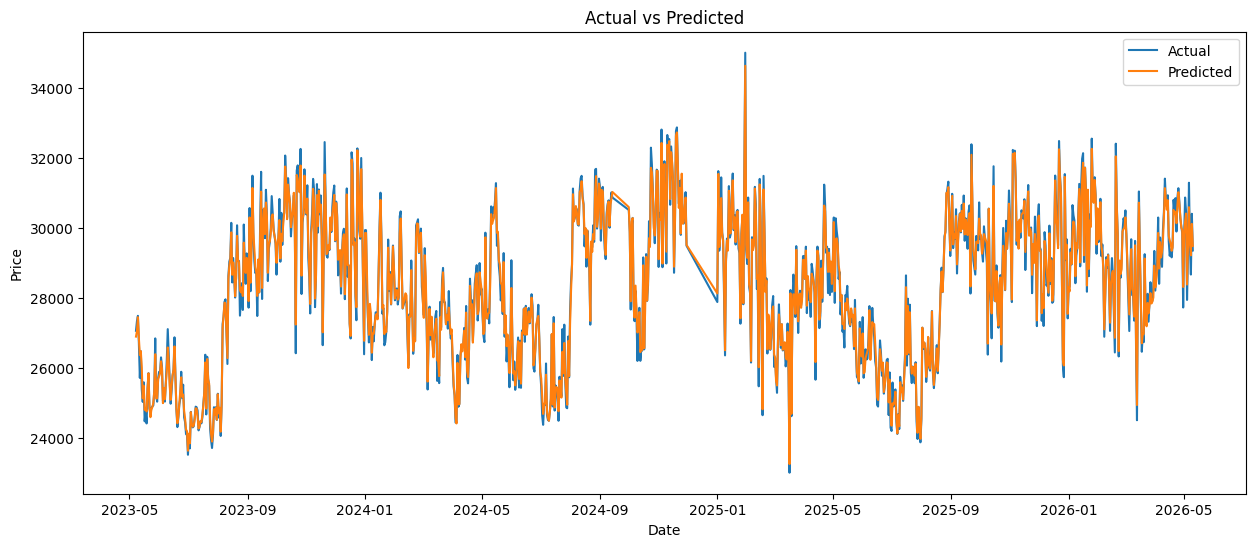

        위판일자          예측단가
0 2026-05-11  29308.980469
1 2026-05-12  29504.898438
2 2026-05-13  29931.972656
3 2026-05-14  29207.632812
4 2026-05-15  29153.396484
5 2026-05-16  29417.144531
6 2026-05-17  29182.582031
이미 최신 데이터입니다.
이미 최신 데이터입니다.
가자미: 1165260개 저장 완료
넙치: 188946개 저장 완료
대게: 49762개 저장 완료
대구: 547888개 저장 완료
문어: 1237892개 저장 완료
아귀: 151069개 저장 완료
전체 어종 분리 완료
가자미 완료
        위판일자           단가
0 2023-05-01  6569.039838
1 2023-05-02  6149.235348
2 2023-05-03  6378.032043
3 2023-05-04  6253.527351
4 2023-05-05  6376.238497
가자미 모델 평가
MAE  : 62.82
RMSE : 86.86
R2   : 0.9726


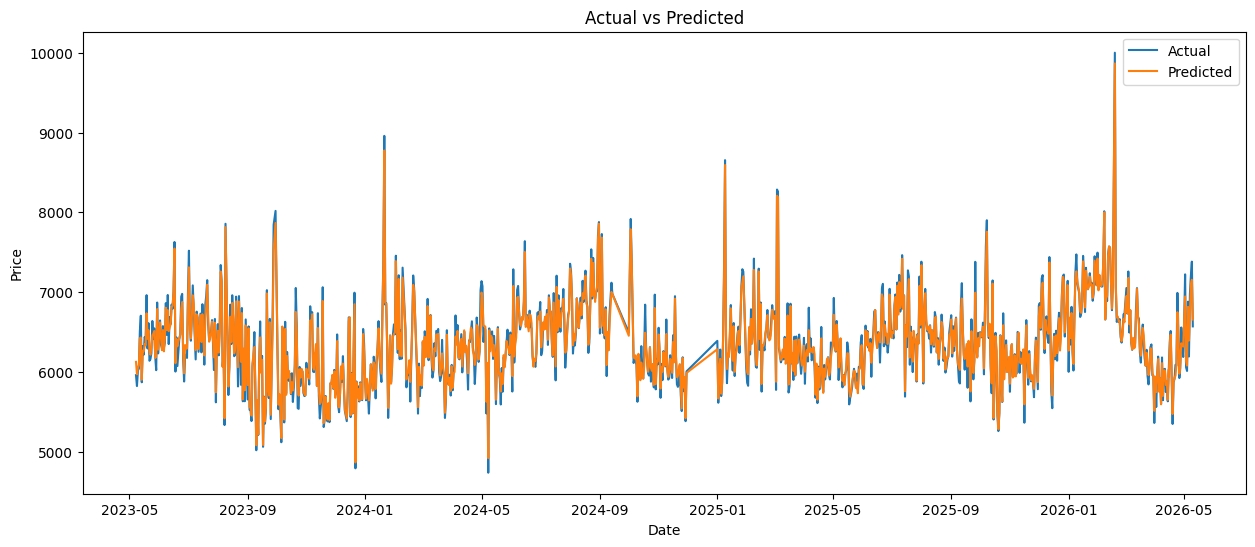

        위판일자         예측단가
0 2026-05-11  6739.551270
1 2026-05-12  6722.254395
2 2026-05-13  6790.494629
3 2026-05-14  6893.349609
4 2026-05-15  6851.630371
5 2026-05-16  6958.219238
6 2026-05-17  6467.214355


In [150]:
#간단한 ui
import tkinter as tk
from tkinter import ttk, messagebox
import threading

# =========================
# 메인 함수들
# =========================
# update_fish_data()
# split_fish_data()
# make_daily_price(fish_name)
# update_weather_data()
# evaluate_fish_model(fish_name)
# predict_7days(result)

# =========================
# UI 함수
# =========================

result_model = None


def log(msg):
    text_log.insert(tk.END, msg + '\n')
    text_log.see(tk.END)


def run_all():

    global result_model

    fish_name = fish_var.get()

    try:

        log('===== 데이터 최신화 시작 =====')

        update_fish_data()
        log('수산물 데이터 최신화 완료')

        update_weather_data()
        log('날씨 데이터 최신화 완료')

        log('===== 어종 분리 =====')

        split_fish_data()

        log('===== 일별 데이터 생성 =====')

        make_daily_price(fish_name)

        log(f'{fish_name} 일별 데이터 생성 완료')

        log('===== 모델 생성 =====')

        result_model = evaluate_fish_model(fish_name)

        log('모델 생성 완료')

        log('===== 7일 예측 =====')

        pred_df = predict_7days(result_model)

        log(pred_df.to_string())

        messagebox.showinfo(
            '완료',
            f'{fish_name} 예측 완료'
        )

    except Exception as e:

        log(f'에러 발생: {e}')

        messagebox.showerror(
            '에러',
            str(e)
        )


def start_thread():

    thread = threading.Thread(target=run_all)

    thread.start()


# =========================
# tkinter UI
# =========================

root = tk.Tk()

root.title('수산물 가격 예측 시스템')

root.geometry('700x600')

# 제목
title = tk.Label(
    root,
    text='수산물 가격 예측 시스템',
    font=('맑은 고딕', 18, 'bold')
)

title.pack(pady=10)

# 어종 선택
frame = tk.Frame(root)

frame.pack(pady=10)

label = tk.Label(
    frame,
    text='어종 선택:',
    font=('맑은 고딕', 12)
)

label.pack(side=tk.LEFT, padx=5)

fish_var = tk.StringVar()

fish_combo = ttk.Combobox(
    frame,
    textvariable=fish_var,
    state='readonly',
    width=20
)

fish_combo['values'] = (
    '문어',
    '가자미',
    '넙치',
    '대게',
    '대구',
    '아귀'
)

fish_combo.current(0)

fish_combo.pack(side=tk.LEFT)

# 실행 버튼
run_button = tk.Button(
    root,
    text='예측 시작',
    font=('맑은 고딕', 12, 'bold'),
    bg='skyblue',
    command=start_thread
)

run_button.pack(pady=10)

# 로그창
text_log = tk.Text(
    root,
    height=25,
    width=85,
    font=('Consolas', 10)
)

text_log.pack(pady=10)

# 스크롤바
scrollbar = tk.Scrollbar(root)

scrollbar.pack(side=tk.RIGHT, fill=tk.Y)

text_log.config(yscrollcommand=scrollbar.set)

scrollbar.config(command=text_log.yview)

root.mainloop()